In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from sklearn.metrics import roc_auc_score, log_loss

In [ ]:
pasta = r'C:\Users\vitor\OneDrive\Documentos\Github\previsao_incendios\dados'
arquivos = os.listdir(pasta)
dfs = []

for arquivo in arquivos:
    if arquivo.startswith('focos_br') and arquivo.endswith('.csv'):
        caminho = os.path.join(pasta, arquivo)
            
            # Lê em pedaços de 100 mil linhas
        for chunk in pd.read_csv(caminho, sep=',', encoding='utf-8', chunksize=100000):
            dfs.append(chunk)

df_completo = pd.concat(dfs, ignore_index=True)

In [ ]:
df_completo.shape

(16287563, 13)

In [ ]:
df =df_completo.sample(frac=0.01, random_state=42) #para faciltar o processamento, peguei apenas 10% dos dados, mas o ideal é usar o df_completo para treinar o modelo.

In [ ]:
df.shape

(162876, 13)

In [ ]:
df.head()

,latitude,longitude,data_pas,satelite,pais,estado,municipio,bioma,numero_dias_sem_chuva,precipitacao,risco_fogo,id_area_industrial,frp
15792566,-4.70184,-46.45336,2025-11-02 23:54:00,TERRA_M-T,Brasil,MARANHÃO,BURITICUPU,Amazônia,4.0,0.90,0.79,0,63.7
7543592,-12.08206,-61.78306,2024-08-28 17:02:00,NPP-375,Brasil,RONDÔNIA,SANTA LUZIA D'OESTE,Amazônia,85.0,0.00,1.00,0,4.5
7028085,-23.58670,-53.90620,2024-08-23 00:55:30,METOP-B,Brasil,PARANÁ,ALTO PARAÍSO,Mata Atlântica,14.0,4.88,-999.00,0,NaN
6988868,-10.18198,-61.95106,2024-08-22 16:50:00,NOAA-21,Brasil,RONDÔNIA,OURO PRETO DO OESTE,Amazônia,6.0,0.00,1.00,0,38.6
2441748,-3.70200,-51.66474,2023-09-28 16:45:00,NPP-375,Brasil,PARÁ,SENADOR JOSÉ PORFÍRIO,Amazônia,5.0,0.31,0.77,0,4.2


In [ ]:
df.dtypes

latitude                 float64
longitude                float64
data_pas                     str
satelite                     str
pais                         str
estado                       str
municipio                    str
bioma                        str
numero_dias_sem_chuva    float64
precipitacao             float64
risco_fogo               float64
id_area_industrial         int64
frp                      float64
dtype: object

In [ ]:
df.info()

<class 'pandas.DataFrame'>
Index: 162876 entries, 15792566 to 11194573
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   latitude               162876 non-null  float64
 1   longitude              162876 non-null  float64
 2   data_pas               162876 non-null  str    
 3   satelite               162876 non-null  str    
 4   pais                   162876 non-null  str    
 5   estado                 162876 non-null  str    
 6   municipio              162876 non-null  str    
 7   bioma                  162876 non-null  str    
 8   numero_dias_sem_chuva  162150 non-null  float64
 9   precipitacao           162150 non-null  float64
 10  risco_fogo             162150 non-null  float64
 11  id_area_industrial     162876 non-null  int64  
 12  frp                    157625 non-null  float64
dtypes: float64(6), int64(1), str(6)
memory usage: 27.0 MB


In [ ]:
df.describe()

,latitude,longitude,numero_dias_sem_chuva,precipitacao,risco_fogo,id_area_industrial,frp
count,162876.000000,162876.000000,162150.000000,162150.000000,162150.000000,162876.0,157625.000000
mean,-9.727873,-51.883817,17.110330,0.620020,-8.831197,0.0,38.589905
std,5.827680,7.264686,108.572475,3.149505,97.592397,0.0,72.206174
min,-33.737600,-73.468230,-999.000000,0.000000,-999.000000,0.0,0.000000
25%,-13.091902,-57.146355,4.000000,0.000000,0.620000,0.0,3.800000
50%,-9.003600,-51.270200,11.000000,0.000000,1.000000,0.0,10.000000
75%,-6.062468,-45.933480,36.000000,0.000000,1.000000,0.0,56.800000
max,5.122440,-34.814360,120.000000,115.240000,1.000000,0.0,5361.900000


In [ ]:
df['data'] = pd.to_datetime(df['data_pas'], errors='coerce')
df['mes'] = df['data'].dt.month
df['ano'] = df['data'].dt.year
df['semana'] = df['data'].dt.isocalendar().week
df['dia'] = df['data'].dt.day

In [ ]:
df['bioma'].unique()

<ArrowStringArray>
['Amazônia', 'Mata Atlântica', 'Cerrado', 'Pantanal', 'Caatinga', 'Pampa']
Length: 6, dtype: str

In [ ]:
df['id_area_industrial'] =df['id_area_industrial'].apply(lambda x: 1 if x > 0 else 0)
df['numero_dias_sem_chuva'] = df['numero_dias_sem_chuva'].apply(lambda x: np.nan if x < 0 else x)
df['risco_fogo'] = df['risco_fogo'].apply(lambda x: np.nan if x < 0 else x)

df['numero_dias_sem_chuva'] = df['numero_dias_sem_chuva'].fillna(df['numero_dias_sem_chuva'].median())
df['risco_fogo'] = df['risco_fogo'].fillna(df['risco_fogo'].median())

df = df.rename(columns={'id_area_industrial': 'area_industrial'})
df = df.drop(columns=['data_pas'])


In [ ]:
df.head()

,latitude,longitude,satelite,pais,estado,municipio,bioma,numero_dias_sem_chuva,precipitacao,risco_fogo,area_industrial,frp,data,mes,ano,semana,dia
15792566,-4.70184,-46.45336,TERRA_M-T,Brasil,MARANHÃO,BURITICUPU,Amazônia,4.0,0.90,0.79,0,63.7,2025-11-02 23:54:00,11,2025,44,2
7543592,-12.08206,-61.78306,NPP-375,Brasil,RONDÔNIA,SANTA LUZIA D'OESTE,Amazônia,85.0,0.00,1.00,0,4.5,2024-08-28 17:02:00,8,2024,35,28
7028085,-23.58670,-53.90620,METOP-B,Brasil,PARANÁ,ALTO PARAÍSO,Mata Atlântica,14.0,4.88,1.00,0,NaN,2024-08-23 00:55:30,8,2024,34,23
6988868,-10.18198,-61.95106,NOAA-21,Brasil,RONDÔNIA,OURO PRETO DO OESTE,Amazônia,6.0,0.00,1.00,0,38.6,2024-08-22 16:50:00,8,2024,34,22
2441748,-3.70200,-51.66474,NPP-375,Brasil,PARÁ,SENADOR JOSÉ PORFÍRIO,Amazônia,5.0,0.31,0.77,0,4.2,2023-09-28 16:45:00,9,2023,39,28


In [ ]:
satelites = df['satelite'].unique()
biomas_maiores_focos = df['bioma'].value_counts()
meses_maiores_focos = df['mes'].value_counts()
estados_maiores_focos = df['estado'].value_counts()

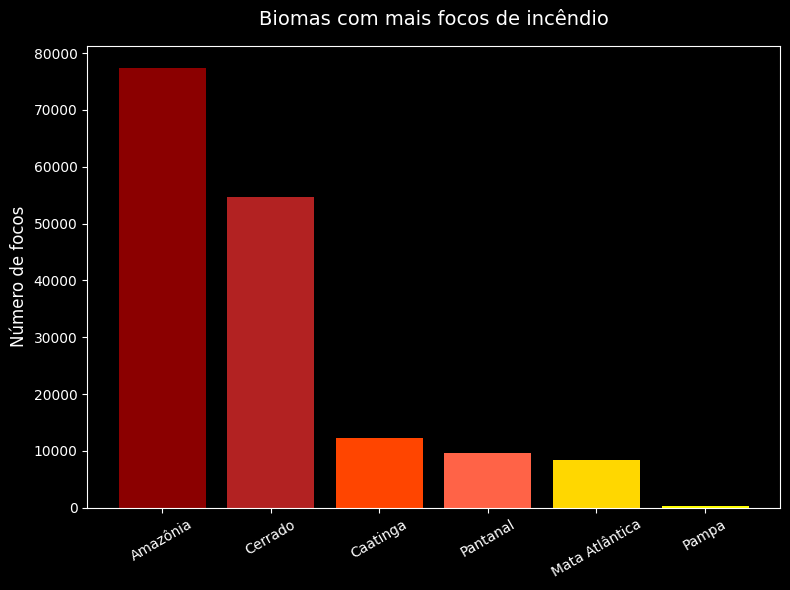

In [ ]:

plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(8,6))

# Paleta neon personalizada
colors = [
    '#8B0000',  # vermelho escuro
    '#B22222',  # vermelho tijolo
    '#FF4500',  # laranja forte
    '#FF6347',  # vermelho tomate
    '#FFD700',  # amarelo ouro
    '#FFFF00'   # amarelo puro
]

ax.bar(
    biomas_maiores_focos.index,
    biomas_maiores_focos.values,
    color=colors
)

ax.set_title("Biomas com mais focos de incêndio", fontsize=14, color="white", pad=15)
ax.set_ylabel("Número de focos", fontsize=12, color="white")

# Tirar grid
ax.grid(False)

# Ajustar ticks
ax.tick_params(axis="x", colors="white", rotation=30)
ax.tick_params(axis="y", colors="white")

plt.tight_layout()
plt.show()


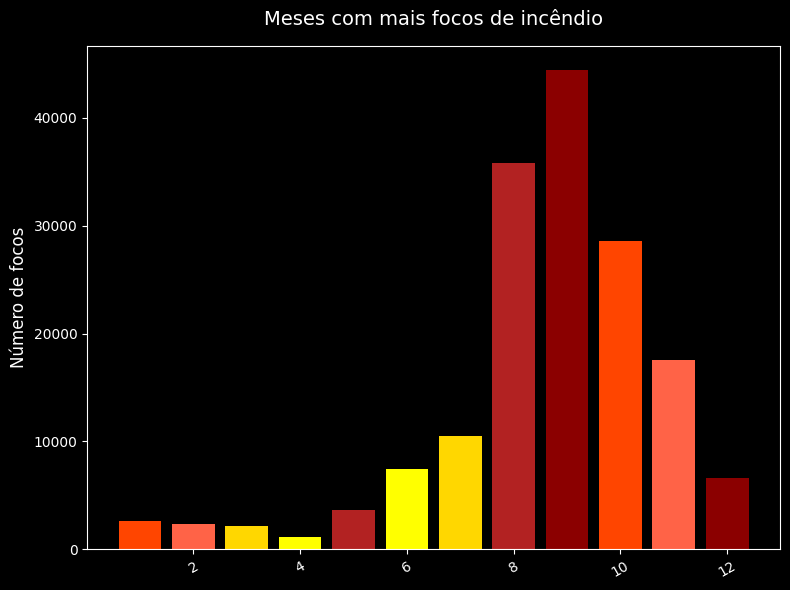

In [ ]:

plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(8,6))

# Paleta neon personalizada
colors = [
    '#8B0000',  # vermelho escuro
    '#B22222',  # vermelho tijolo
    '#FF4500',  # laranja forte
    '#FF6347',  # vermelho tomate
    '#FFD700',  # amarelo ouro
    '#FFFF00'   # amarelo puro
]

ax.bar(
    meses_maiores_focos.index,
    meses_maiores_focos.values,
    color=colors
)

ax.set_title("Meses com mais focos de incêndio", fontsize=14, color="white", pad=15)
ax.set_ylabel("Número de focos", fontsize=12, color="white")

# Tirar grid
ax.grid(False)

# Ajustar ticks
ax.tick_params(axis="x", colors="white", rotation=30)
ax.tick_params(axis="y", colors="white")

plt.tight_layout()
plt.show()


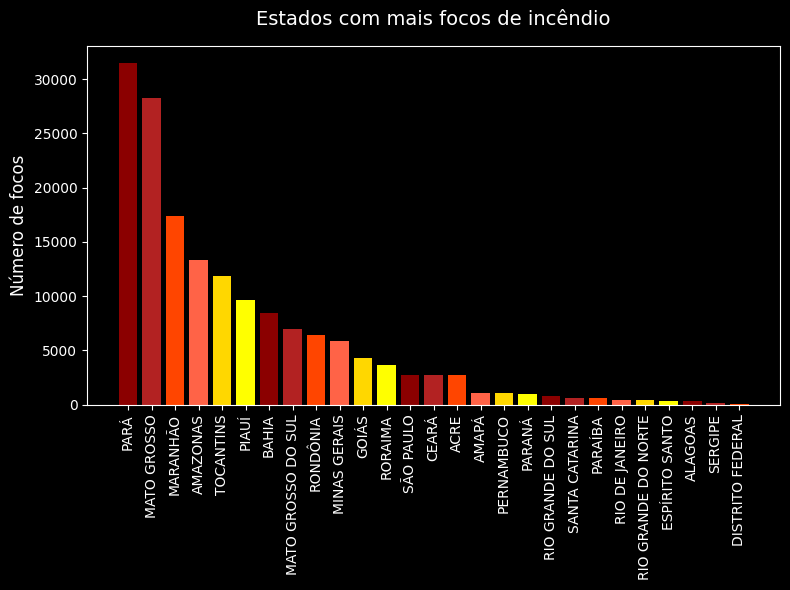

In [ ]:

plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(8,6))

# Paleta neon personalizada
colors = [
    '#8B0000',  # vermelho escuro
    '#B22222',  # vermelho tijolo
    '#FF4500',  # laranja forte
    '#FF6347',  # vermelho tomate
    '#FFD700',  # amarelo ouro
    '#FFFF00'   # amarelo puro
]

ax.bar(
    estados_maiores_focos.index,
    estados_maiores_focos.values,
    color=colors
)

ax.set_title("Estados com mais focos de incêndio", fontsize=14, color="white", pad=15)
ax.set_ylabel("Número de focos", fontsize=12, color="white")

# Tirar grid
ax.grid(False)

# Ajustar ticks
ax.tick_params(axis="x", colors="white", rotation=90)
ax.tick_params(axis="y", colors="white")

plt.tight_layout()
plt.show()


In [ ]:
df.head()

,latitude,longitude,satelite,pais,estado,municipio,bioma,numero_dias_sem_chuva,precipitacao,risco_fogo,area_industrial,frp,data,mes,ano,semana,dia
15792566,-4.70184,-46.45336,TERRA_M-T,Brasil,MARANHÃO,BURITICUPU,Amazônia,4.0,0.90,0.79,0,63.7,2025-11-02 23:54:00,11,2025,44,2
7543592,-12.08206,-61.78306,NPP-375,Brasil,RONDÔNIA,SANTA LUZIA D'OESTE,Amazônia,85.0,0.00,1.00,0,4.5,2024-08-28 17:02:00,8,2024,35,28
7028085,-23.58670,-53.90620,METOP-B,Brasil,PARANÁ,ALTO PARAÍSO,Mata Atlântica,14.0,4.88,1.00,0,NaN,2024-08-23 00:55:30,8,2024,34,23
6988868,-10.18198,-61.95106,NOAA-21,Brasil,RONDÔNIA,OURO PRETO DO OESTE,Amazônia,6.0,0.00,1.00,0,38.6,2024-08-22 16:50:00,8,2024,34,22
2441748,-3.70200,-51.66474,NPP-375,Brasil,PARÁ,SENADOR JOSÉ PORFÍRIO,Amazônia,5.0,0.31,0.77,0,4.2,2023-09-28 16:45:00,9,2023,39,28


In [ ]:
df_incendios = df.drop(columns= ['satelite','pais','data','latitude','longitude','area_industrial',])
df_incendios['incendio'] = 1

df_incendios['precipitacao_total'] = df_incendios['precipitacao'].fillna(0)

df_incendios = df_incendios.groupby(['semana','municipio','estado','ano','mes','dia']).agg(
    incendio_total=('incendio','sum'),
    risco_fogo_medio=('risco_fogo','mean'),
    precipitacao_total=('precipitacao','sum'),
    dias_sem_chuva_max=('numero_dias_sem_chuva','max'),
    bioma=('bioma',  pd.Series.mode) 
).reset_index()

df_incendios['teve_incendio'] = 1


In [ ]:
df_incendios.head()

,semana,municipio,estado,ano,mes,dia,incendio_total,risco_fogo_medio,precipitacao_total,dias_sem_chuva_max,bioma,teve_incendio
0,1,ACARAÚ,CEARÁ,2024,1,4,1,0.46,0.00,11.0,Caatinga,1
1,1,ACARAÚ,CEARÁ,2024,12,31,1,0.93,0.00,11.0,Caatinga,1
2,1,ACOPIARA,CEARÁ,2024,1,5,1,0.98,0.00,3.0,Caatinga,1
3,1,ACOPIARA,CEARÁ,2025,12,30,1,1.00,0.00,7.0,Caatinga,1
4,1,AFONSO CUNHA,MARANHÃO,2024,1,6,1,0.00,14.26,0.0,Cerrado,1


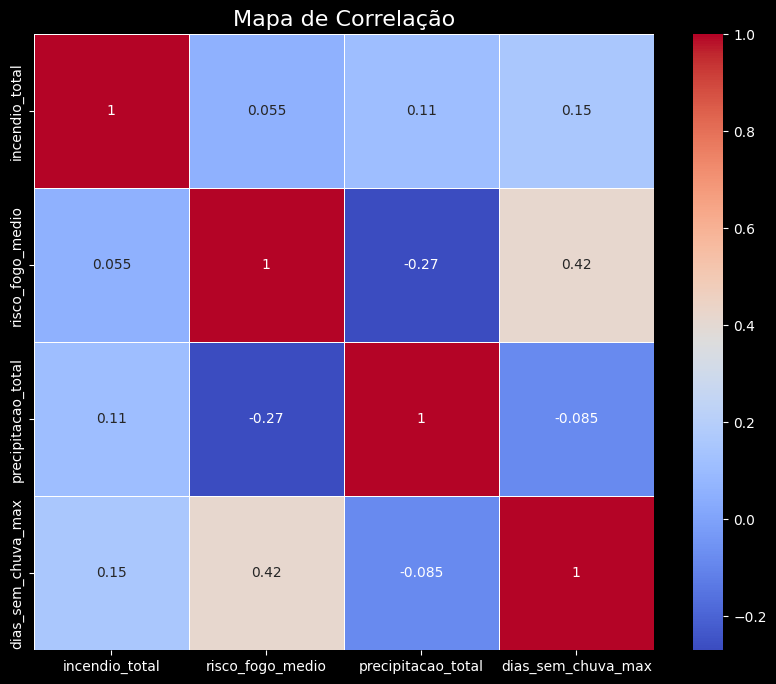

In [ ]:
var_numericas = ['incendio_total', 'risco_fogo_medio', 'precipitacao_total', 'dias_sem_chuva_max']

corr = df_incendios[var_numericas].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Mapa de Correlação", fontsize=16)
plt.show()

In [ ]:
semanas_sem_incendio = df['semana'].unique()

In [ ]:
semanas_sem_incendio

<IntegerArray>
[44, 35, 34, 39, 37, 29, 33, 25, 48, 42,  8, 41, 46, 45, 38, 43, 23,  1, 49,
 27, 21, 36, 28, 32, 10, 18, 31, 13, 50, 30,  2, 47, 24,  3, 19, 26, 15, 40,
 22, 51,  7, 20,  5,  4, 17,  6, 52, 12,  9, 11, 16, 14]
Length: 52, dtype: UInt32

In [ ]:
df_incendios.head()

,semana,municipio,estado,ano,mes,dia,incendio_total,risco_fogo_medio,precipitacao_total,dias_sem_chuva_max,bioma,teve_incendio
0,1,ACARAÚ,CEARÁ,2024,1,4,1,0.46,0.00,11.0,Caatinga,1
1,1,ACARAÚ,CEARÁ,2024,12,31,1,0.93,0.00,11.0,Caatinga,1
2,1,ACOPIARA,CEARÁ,2024,1,5,1,0.98,0.00,3.0,Caatinga,1
3,1,ACOPIARA,CEARÁ,2025,12,30,1,1.00,0.00,7.0,Caatinga,1
4,1,AFONSO CUNHA,MARANHÃO,2024,1,6,1,0.00,14.26,0.0,Cerrado,1


In [ ]:
# Criar registros negativos sintéticos
negativos = []


n = len(df_incendios)

df_negativos = pd.DataFrame({
    'semana': df_incendios['semana'].values,
    'municipio': df_incendios['municipio'].values,
    'estado': df_incendios['estado'].values,
    'ano': df_incendios['ano'].values,
    'mes': df_incendios['mes'].values,
    'dia': df_incendios['dia'].values,
    'incendio_total': np.zeros(n, dtype=int),
    'risco_fogo_medio': np.random.uniform(
        0, np.quantile(df_incendios['risco_fogo_medio'], 0.2), size=n
    ),
    'precipitacao_total': np.random.uniform(20, 100, size=n),
    'dias_sem_chuva_max': np.random.randint(0, 3, size=n),
    'bioma': df_incendios['bioma'].values,
    'teve_incendio': np.zeros(n, dtype=int)
})

# Concatenar positivos e negativos
df_final = pd.concat([df_incendios, df_negativos], ignore_index=True)


In [ ]:
df_final['semana_sin'] = np.sin(2 * np.pi * df_final['semana'] / 52)
df_final['semana_cos'] = np.cos(2 * np.pi * df_final['semana'] / 52)

In [ ]:
for col in ['municipio', 'estado', 'bioma']:
    le = LabelEncoder()
    df_final[col] = le.fit_transform(df_final[col].astype(str))
df_2023 = df_final[df_final['ano'] == 2023]
df_2023 = df_2023.drop(columns=['ano','dia'])

In [ ]:
df_final['teve_incendio'].value_counts()

teve_incendio
1    80024
0    80024
Name: count, dtype: int64

In [ ]:
df_final.head()

,semana,municipio,estado,ano,mes,dia,incendio_total,risco_fogo_medio,precipitacao_total,dias_sem_chuva_max,bioma,teve_incendio,semana_sin,semana_cos
0,1,15,5,2024,1,4,1,0.46,0.00,11.0,7,1,0.120537,0.992709
1,1,15,5,2024,12,31,1,0.93,0.00,11.0,7,1,0.120537,0.992709
2,1,19,5,2024,1,5,1,0.98,0.00,3.0,7,1,0.120537,0.992709
3,1,19,5,2025,12,30,1,1.00,0.00,7.0,7,1,0.120537,0.992709
4,1,29,9,2024,1,6,1,0.00,14.26,0.0,8,1,0.120537,0.992709


In [ ]:
df_final.dtypes

semana                 UInt32
municipio               int64
estado                  int64
ano                     int32
mes                     int32
dia                     int32
incendio_total          int64
risco_fogo_medio      float64
precipitacao_total    float64
dias_sem_chuva_max    float64
bioma                   int64
teve_incendio           int64
semana_sin            Float64
semana_cos            Float64
dtype: object

In [ ]:
x = df_final.drop(columns=['teve_incendio','dia','estado','semana','incendio_total','municipio','ano','risco_fogo_medio'])

y = df_final['teve_incendio']

x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y,test_size=0.2, random_state=42)
x_train = x_train.astype(float)

smote = SMOTE(random_state=42)
x_train_res, y_train_res = smote.fit_resample(x_train, y_train)

xgb_clf = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.8,
    random_state=42,
    scale_pos_weight=15,
    reg_lambda=1,  # L2 regularization
    reg_alpha=0.1   # L1 regularization  
)

xgb_clf.fit(x_train_res, y_train_res)

y_pred_proba = xgb_clf.predict_proba(x_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print("Log Loss:", log_loss(y_test, y_pred_proba))

ROC-AUC: 0.9994629158081945
Log Loss: 0.037991430829914824


In [ ]:
display(y_pred_proba)

In [ ]:
print("Antes do SMOTE:", y_train.value_counts())
print("Depois do SMOTE:", y_train_res.value_counts())


Antes do SMOTE: teve_incendio
0    64019
1    64019
Name: count, dtype: int64
Depois do SMOTE: teve_incendio
0    64019
1    64019
Name: count, dtype: int64


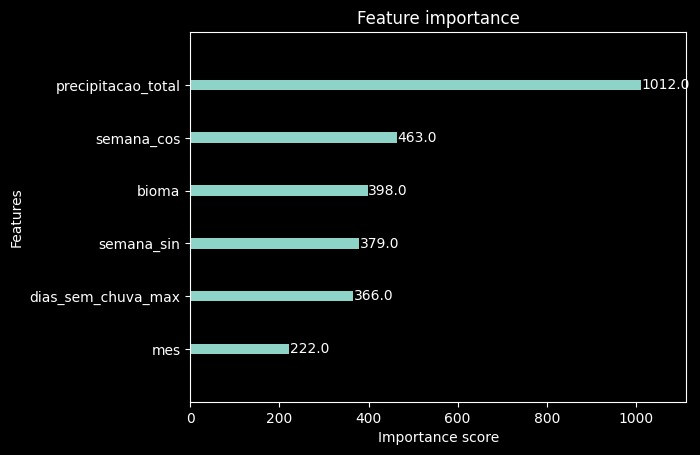

In [ ]:
xgb.plot_importance(xgb_clf , grid = False)
plt.show()